In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Random Forest flat file
rf = pd.read_csv("test_pred_true_selected_horizons- Random Forest.csv")

# Excel file paths
file_gwn_gru_lstm = "Graphwavenet-GRU-LSTM.xlsx"
file_gwn_lstm = "test_pred_true_selected_horizons- Graphwavenet-LSTM.xlsx"
file_gwn_gru = "test_pred_true_selected_horizons- Graphwavenet-GRU.xlsx"

In [8]:
rf = rf.copy()
rf.columns = [c.lower().strip() for c in rf.columns]

# Rename horizon column if needed
if "horizon_h" in rf.columns:
    rf = rf.rename(columns={"horizon_h": "horizon"})

# Keep only what we need
rf = rf[["timestamp", "station", "horizon", "y_true", "y_pred"]].copy()
rf["model"] = "Random Forest"

print(rf.head())
print(rf.columns)

             timestamp  station  horizon  y_true      y_pred          model
0  2024-12-01 11:00:00   308511       12   417.0   429.62564  Random Forest
1  2024-12-01 11:00:00   308512       12  1941.0  1962.44460  Random Forest
2  2024-12-01 11:00:00   311831       12   129.0   142.52913  Random Forest
3  2024-12-01 11:00:00   311832       12   315.0   328.57492  Random Forest
4  2024-12-01 11:00:00   311844       12   455.0   545.16810  Random Forest
Index(['timestamp', 'station', 'horizon', 'y_true', 'y_pred', 'model'], dtype='object')


In [9]:
def load_graph_model_from_excel(filepath, model_name):
    horizons = [12, 24, 48, 72]
    all_parts = []

    for h in horizons:
        pred_sheet = f"pred_h{h}"
        true_sheet = f"true_h{h}"

        pred_df = pd.read_excel(filepath, sheet_name=pred_sheet)
        true_df = pd.read_excel(filepath, sheet_name=true_sheet)

        pred_df.columns = pred_df.columns.map(str)
        true_df.columns = true_df.columns.map(str)

        # Melt wide station columns into long format
        pred_long = pred_df.melt(
            id_vars=["target_time"],
            var_name="station",
            value_name="y_pred"
        )
        true_long = true_df.melt(
            id_vars=["target_time"],
            var_name="station",
            value_name="y_true"
        )

        merged = pred_long.merge(
            true_long,
            on=["target_time", "station"],
            how="inner"
        )

        merged = merged.rename(columns={"target_time": "timestamp"})
        merged["horizon"] = h
        merged["model"] = model_name

        all_parts.append(merged)

    out = pd.concat(all_parts, ignore_index=True)
    return out[["timestamp", "station", "horizon", "y_true", "y_pred", "model"]]

In [10]:
gwn_gru_lstm = load_graph_model_from_excel(file_gwn_gru_lstm, "Proposed")
gwn_lstm = load_graph_model_from_excel(file_gwn_lstm, "GWN-LSTM")
gwn_gru = load_graph_model_from_excel(file_gwn_gru, "GWN-GRU")

In [11]:
df_all = pd.concat([rf, gwn_gru_lstm, gwn_lstm, gwn_gru], ignore_index=True)

# Clean types
df_all["horizon"] = pd.to_numeric(df_all["horizon"], errors="coerce")
df_all["y_true"] = pd.to_numeric(df_all["y_true"], errors="coerce")
df_all["y_pred"] = pd.to_numeric(df_all["y_pred"], errors="coerce")

# Drop bad rows if any
df_all = df_all.dropna(subset=["horizon", "y_true", "y_pred"])

# Error columns
df_all["abs_error"] = (df_all["y_true"] - df_all["y_pred"]).abs()
df_all["residual"] = df_all["y_true"] - df_all["y_pred"]

print(df_all.head())
print(df_all["model"].value_counts())
print(df_all["horizon"].value_counts())

             timestamp station  horizon  y_true      y_pred          model  \
0  2024-12-01 11:00:00  308511       12   417.0   429.62564  Random Forest   
1  2024-12-01 11:00:00  308512       12  1941.0  1962.44460  Random Forest   
2  2024-12-01 11:00:00  311831       12   129.0   142.52913  Random Forest   
3  2024-12-01 11:00:00  311832       12   315.0   328.57492  Random Forest   
4  2024-12-01 11:00:00  311844       12   455.0   545.16810  Random Forest   

   abs_error  residual  
0   12.62564 -12.62564  
1   21.44460 -21.44460  
2   13.52913 -13.52913  
3   13.57492 -13.57492  
4   90.16810 -90.16810  
model
Proposed         4902132
GWN-LSTM         4902132
GWN-GRU          4902132
Random Forest     807600
Name: count, dtype: int64
horizon
12    3878499
24    3878499
48    3878499
72    3878499
Name: count, dtype: int64


C:\Users\attafuro\AppData\Local\Temp\ipykernel_40696\2284885313.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)
C:\Users\attafuro\AppData\Local\Temp\ipykernel_40696\2284885313.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)
C:\Users\attafuro\AppData\Local\Temp\ipykernel_40696\2284885313.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)
C:\Users\attafuro\AppData\Local\Temp\ipykernel_40696\2284885313.py:13: MatplotlibDeprecationWarning: The 'labels' paramet

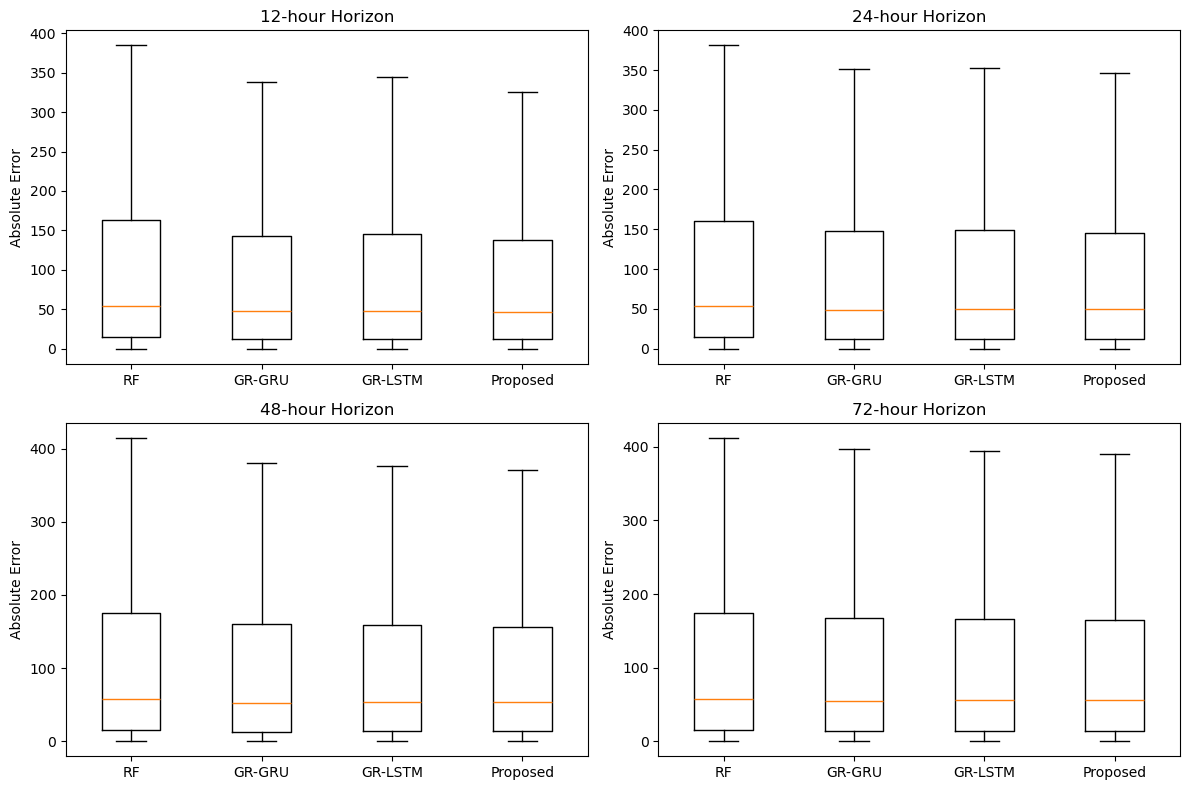

In [14]:
horizons = [12, 24, 48, 72]
model_order = ["Random Forest", "GWN-GRU", "GWN-LSTM", "Proposed"]
labels = ["RF", "GR-GRU", "GR-LSTM", "Proposed"]

plt.figure(figsize=(12, 8))

for i, h in enumerate(horizons, 1):
    plt.subplot(2, 2, i)
    subset = df_all[df_all["horizon"] == h]

    data = [subset.loc[subset["model"] == m, "abs_error"].values for m in model_order]

    plt.boxplot(data, labels=labels, showfliers=False)
    plt.title(f"{h}-hour Horizon")
    plt.ylabel("Absolute Error")

plt.tight_layout()
plt.savefig("error_boxplot_absolute.png", dpi=300, bbox_inches="tight")
plt.show()

C:\Users\attafuro\AppData\Local\Temp\ipykernel_40696\3473686548.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)
C:\Users\attafuro\AppData\Local\Temp\ipykernel_40696\3473686548.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)
C:\Users\attafuro\AppData\Local\Temp\ipykernel_40696\3473686548.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=labels, showfliers=False)
C:\Users\attafuro\AppData\Local\Temp\ipykernel_40696\3473686548.py:9: MatplotlibDeprecationWarning: The 'labels' parameter o

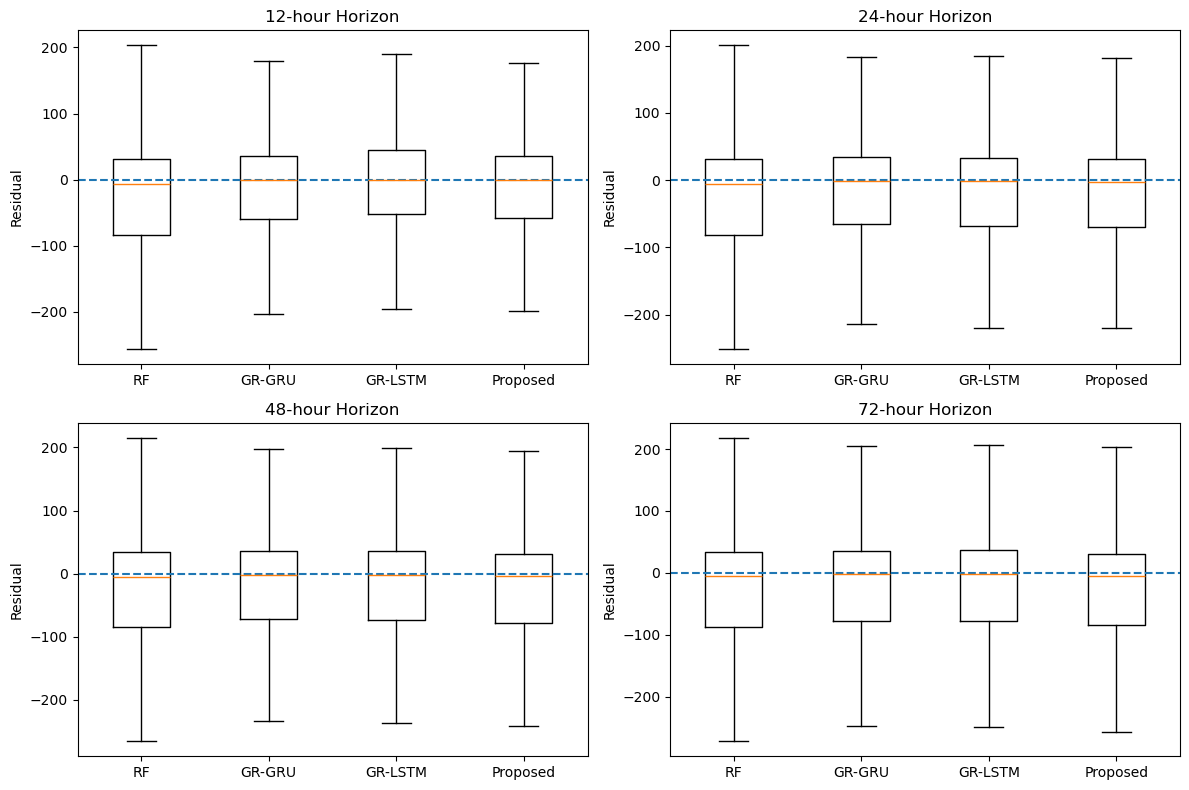

In [15]:
plt.figure(figsize=(12, 8))

for i, h in enumerate(horizons, 1):
    plt.subplot(2, 2, i)
    subset = df_all[df_all["horizon"] == h]

    data = [subset.loc[subset["model"] == m, "residual"].values for m in model_order]

    plt.boxplot(data, labels=labels, showfliers=False)
    plt.axhline(0, linestyle="--")
    plt.title(f"{h}-hour Horizon")
    plt.ylabel("Residual")

plt.tight_layout()
plt.savefig("error_boxplot_residual.png", dpi=300, bbox_inches="tight")
plt.show()